# 🎨 AI Logo Generator using DCGAN

| Item | Detail |
|---|---|
| **Architecture** | Deep Convolutional GAN (DCGAN) |
| **Framework** | PyTorch |
| **Input** | Random noise vector (z ∈ ℝ¹⁰⁰) |
| **Output** | 64×64 RGB logo images |
| **Device** | CPU-compatible |

---
> **Adversarial Learning Concept:**  
> A GAN consists of two networks competing in a minimax game:
> - **Generator (G):** Learns to synthesize fake images that look real  
> - **Discriminator (D):** Learns to tell real images from fakes  
> They improve each other until G produces convincing logos.


## 📦 Step 1 — Imports & Hyperparameters

In [11]:
import os, torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as transforms
import torchvision.datasets as datasets, torchvision.utils as vutils
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
import numpy as np
from torch.utils.data import DataLoader, TensorDataset


# ── Hyperparameters ─────────────────────────────────────────────────────
BATCH_SIZE    = 64       # Images per training step
IMAGE_SIZE    = 64     # Resize all logos to 64×64 pixels
NOISE_DIM     = 100    # Length of random noise vector (latent space)
NUM_EPOCHS    = 20    # Full passes over the dataset
LEARNING_RATE = 0.0002 # Adam LR (DCGAN paper standard)
BETA1         = 0.5    # Adam β₁ — lower value stabilises GAN training
NGF           = 32     # Generator feature map base width
NDF           = 32     # Discriminator feature map base width
NUM_CHANNELS  = 3      # RGB

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch {torch.__version__}")


Device: cpu
PyTorch 2.9.0+cpu


## 🗂️ Step 2 — Data Loading & Preprocessing

**Pipeline:**  
`Resize(64)` → `CenterCrop(64)` → `ToTensor [0,1]` → `Normalize → [-1,1]`

Normalizing to **[-1, 1]** matches the Generator's `Tanh` output range.

**Folder structure expected:**
```
logo_dataset/
└── logos/
    ├── logo1.png
    ├── logo2.jpg
    └── ...
```


## 🏗️ Step 3 — Generator Network

**Role of the noise vector (z):**  
A random vector sampled from 𝒩(0, I) is the only input. Each different z produces a different logo. The Generator *learns* to map this random space to the image space.

**Architecture — upsampling with `ConvTranspose2d`:**

| Layer | Output Shape | Activation |
|---|---|---|
| Input noise | 100 × 1 × 1 | — |
| ConvT2d + BN | 256 × 4 × 4 | ReLU |
| ConvT2d + BN | 128 × 8 × 8 | ReLU |
| ConvT2d + BN | 64 × 16 × 16 | ReLU |
| ConvT2d + BN | 32 × 32 × 32 | ReLU |
| ConvT2d | 3 × 64 × 64 | **Tanh** |

- **BatchNorm** — stabilises training, prevents mode collapse  
- **ReLU** — promotes gradient flow  
- **Tanh** — output in [-1, 1] to match normalised real images


In [12]:
def get_dataloader(data_dir):
    """Load real logo images using ImageFolder."""
    transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),   # Shift [0,1] → [-1,1]
                             (0.5, 0.5, 0.5)),
    ])
    dataset    = datasets.ImageFolder(root=data_dir, transform=transform)
    from torch.utils.data import Subset
    dataset = Subset(dataset, range(5000))
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE,
                            shuffle=True, num_workers=0, drop_last=True)
    print(f"Loaded {len(dataset)} images from '{data_dir}'")
    return dataloader

def demo_dataloader():
    """Synthetic data for architecture demo (no real dataset needed)."""
    imgs   = torch.tanh(torch.randn(128, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE))
    labels = torch.zeros(128, dtype=torch.long)
    return DataLoader(TensorDataset(imgs, labels),
                      batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

DATA_DIR = "/kaggle/input/datasets/siddharthkumarsah/logo-dataset-2341-classes-and-167140-images"
if os.path.exists(DATA_DIR):
    dataloader = get_dataloader(DATA_DIR)
else:
    print(f"'{DATA_DIR}' not found → running DEMO MODE with synthetic data.")
    dataloader = demo_dataloader()

print(f"Batches per epoch: {len(dataloader)}")


Loaded 5000 images from '/kaggle/input/datasets/siddharthkumarsah/logo-dataset-2341-classes-and-167140-images'
Batches per epoch: 78


In [13]:
class Generator(nn.Module):
    """
    DCGAN Generator: noise vector → fake logo image.
    Uses ConvTranspose2d (fractionally strided convolution) to upsample.
    """
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # Block 1: 100×1×1 → 256×4×4
            nn.ConvTranspose2d(NOISE_DIM, NGF*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(NGF*8), nn.ReLU(True),
            # Block 2: 256×4×4 → 128×8×8
            nn.ConvTranspose2d(NGF*8, NGF*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF*4), nn.ReLU(True),
            # Block 3: 128×8×8 → 64×16×16
            nn.ConvTranspose2d(NGF*4, NGF*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF*2), nn.ReLU(True),
            # Block 4: 64×16×16 → 32×32×32
            nn.ConvTranspose2d(NGF*2, NGF,   4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF),   nn.ReLU(True),
            # Block 5: 32×32×32 → 3×64×64  (RGB output)
            nn.ConvTranspose2d(NGF, NUM_CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()   # Output ∈ [-1, 1]
        )

    def forward(self, z):
        return self.main(z)

G = Generator().to(device)
print(f"Generator parameters: {sum(p.numel() for p in G.parameters()):,}")
print(G)


Generator parameters: 1,100,224
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=F

## 🔍 Step 4 — Discriminator Network

**Architecture — downsampling with strided `Conv2d`:**

| Layer | Output Shape | Activation |
|---|---|---|
| Input image | 3 × 64 × 64 | — |
| Conv2d | 32 × 32 × 32 | LeakyReLU(0.2) |
| Conv2d + BN | 64 × 16 × 16 | LeakyReLU(0.2) |
| Conv2d + BN | 128 × 8 × 8 | LeakyReLU(0.2) |
| Conv2d + BN | 256 × 4 × 4 | LeakyReLU(0.2) |
| Conv2d | 1 × 1 × 1 | **Sigmoid** |

- **No pooling** — strided convolution lets the model learn downsampling  
- **LeakyReLU(0.2)** — prevents dying ReLU problem in discriminator  
- **No BN on first layer** — preserves raw pixel statistics  
- **Sigmoid** — outputs probability ∈ [0, 1] (0 = Fake, 1 = Real)


In [14]:
class Discriminator(nn.Module):
    """
    DCGAN Discriminator: image → P(real).
    Uses strided Conv2d (no pooling) for learnable downsampling.
    """
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # Block 1: 3×64×64 → 32×32×32  (NO BatchNorm on first layer)
            nn.Conv2d(NUM_CHANNELS, NDF,   4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # Block 2: 32×32×32 → 64×16×16
            nn.Conv2d(NDF,   NDF*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*2), nn.LeakyReLU(0.2, inplace=True),
            # Block 3: 64×16×16 → 128×8×8
            nn.Conv2d(NDF*2, NDF*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*4), nn.LeakyReLU(0.2, inplace=True),
            # Block 4: 128×8×8 → 256×4×4
            nn.Conv2d(NDF*4, NDF*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*8), nn.LeakyReLU(0.2, inplace=True),
            # Block 5: 256×4×4 → 1×1×1  (real/fake score)
            nn.Conv2d(NDF*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()   # Output ∈ [0, 1]
        )

    def forward(self, img):
        return self.main(img)

D = Discriminator().to(device)
print(f"Discriminator parameters: {sum(p.numel() for p in D.parameters()):,}")
print(D)


Discriminator parameters: 694,656
Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

## ⚖️ Step 5 — Weight Initialisation

DCGAN paper specifies initialising all weights from 𝒩(0, 0.02).  
This ensures stable gradients from the very first iteration.


In [15]:
def weights_init(m):
    """
    DCGAN weight initialisation:
      Conv layers  → Normal(0, 0.02)
      BatchNorm    → Normal(1, 0.02), bias=0
    """
    cls = m.__class__.__name__
    if cls.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif cls.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G.apply(weights_init)
D.apply(weights_init)
print("Weights initialised (Normal μ=0, σ=0.02)")


Weights initialised (Normal μ=0, σ=0.02)


## 🗺️ Architecture Diagram

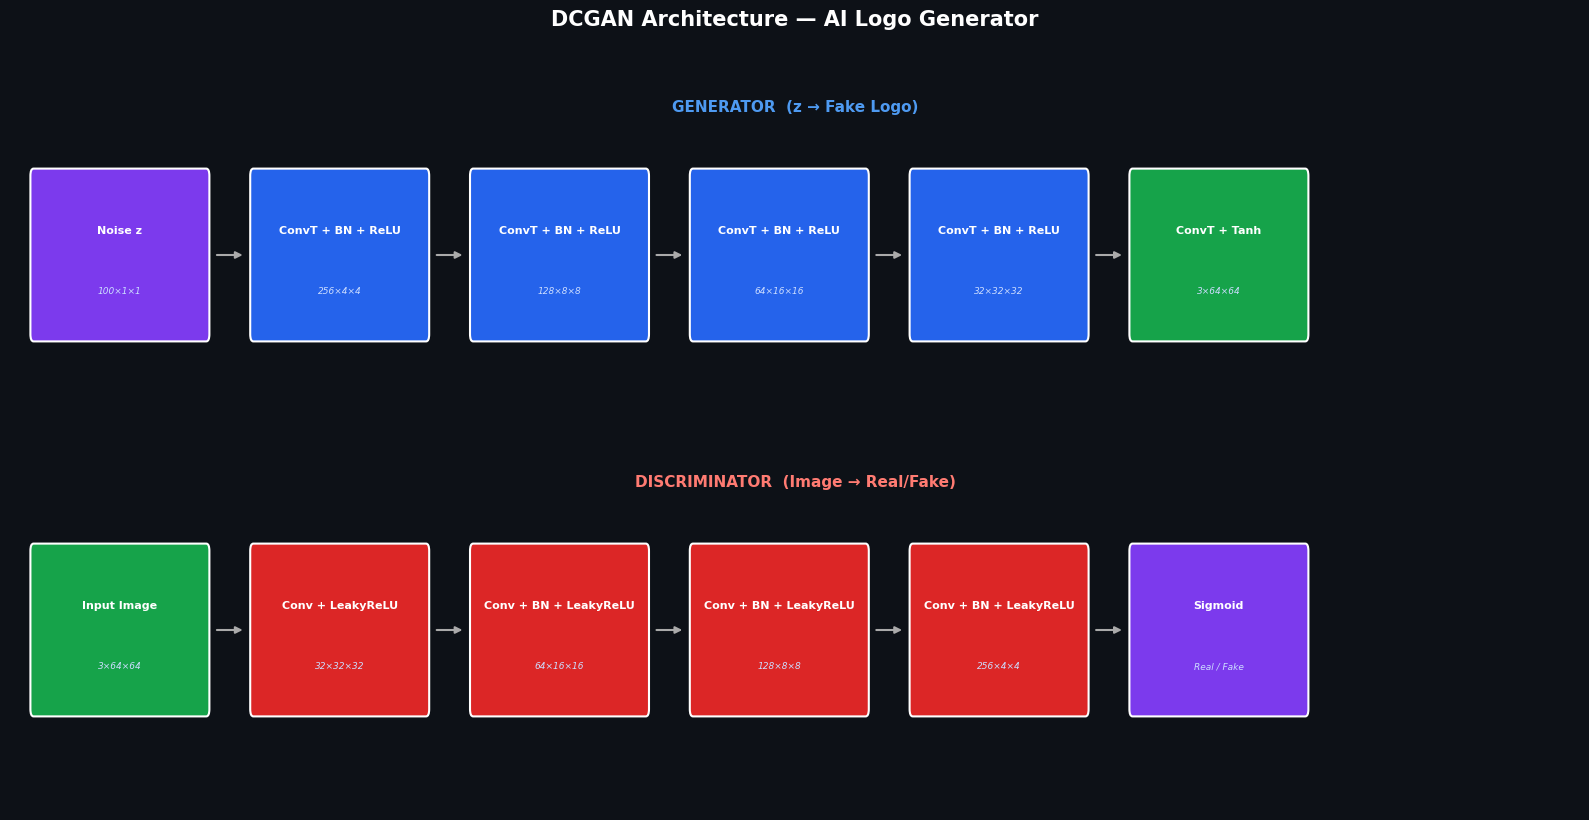

In [16]:
import matplotlib.pyplot as plt

def draw_arch_diagram():
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    fig.patch.set_facecolor('#0d1117')

    fig.suptitle(
        "DCGAN Architecture — AI Logo Generator",
        fontsize=15,
        fontweight='bold',
        color='white',
        y=1.02
    )

    # Block drawing function
    def block(ax, x, y, label, shape, fc, ec='white'):
        from matplotlib.patches import FancyBboxPatch

        b = FancyBboxPatch(
            (x-0.55, y-0.22),
            1.1,
            0.44,
            boxstyle="round,pad=0.02",
            facecolor=fc,
            edgecolor=ec,
            lw=1.5,
            zorder=3
        )

        ax.add_patch(b)

        ax.text(
            x, y+0.07,
            label,
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold',
            color='white'
        )

        ax.text(
            x, y-0.1,
            shape,
            ha='center',
            va='center',
            fontsize=6.5,
            color='#ccddff',
            style='italic'
        )

    # Arrow function
    def arrow(ax, x1, x2, y):
        ax.annotate(
            "",
            xy=(x2, y),
            xytext=(x1, y),
            arrowprops=dict(arrowstyle="-|>", color='#aaa', lw=1.5)
        )

    # ---------------------------
    # Generator
    # ---------------------------
    ax = axes[0]
    ax.set_facecolor('#161b22')
    ax.set_xlim(0,10)
    ax.set_ylim(0,1)
    ax.axis('off')

    ax.text(
        5,0.9,
        "GENERATOR  (z → Fake Logo)",
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='#4e9af1'
    )

    gen = [
        (0.7,"Noise z","100×1×1","#7c3aed"),
        (2.1,"ConvT + BN + ReLU","256×4×4","#2563eb"),
        (3.5,"ConvT + BN + ReLU","128×8×8","#2563eb"),
        (4.9,"ConvT + BN + ReLU","64×16×16","#2563eb"),
        (6.3,"ConvT + BN + ReLU","32×32×32","#2563eb"),
        (7.7,"ConvT + Tanh","3×64×64","#16a34a")
    ]

    for x,label,shape,color in gen:
        block(ax, x, 0.5, label, shape, color)

    for i in range(len(gen)-1):
        arrow(ax, gen[i][0]+0.6, gen[i+1][0]-0.6, 0.5)

    # ---------------------------
    # Discriminator
    # ---------------------------
    ax = axes[1]
    ax.set_facecolor('#161b22')
    ax.set_xlim(0,10)
    ax.set_ylim(0,1)
    ax.axis('off')

    ax.text(
        5,0.9,
        "DISCRIMINATOR  (Image → Real/Fake)",
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='#ff7b72'
    )

    disc = [
        (0.7,"Input Image","3×64×64","#16a34a"),
        (2.1,"Conv + LeakyReLU","32×32×32","#dc2626"),
        (3.5,"Conv + BN + LeakyReLU","64×16×16","#dc2626"),
        (4.9,"Conv + BN + LeakyReLU","128×8×8","#dc2626"),
        (6.3,"Conv + BN + LeakyReLU","256×4×4","#dc2626"),
        (7.7,"Sigmoid","Real / Fake","#7c3aed")
    ]

    for x,label,shape,color in disc:
        block(ax, x, 0.5, label, shape, color)

    for i in range(len(disc)-1):
        arrow(ax, disc[i][0]+0.6, disc[i+1][0]-0.6, 0.5)

    plt.tight_layout()
    plt.show()


# Run the function
draw_arch_diagram()

In [ ]:
os.makedirs("outputs/progress", exist_ok=True)

criterion   = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))

# Fixed noise → visualise same samples each epoch to track progress
fixed_noise = torch.randn(16, NOISE_DIM, 1, 1, device=device)

G_losses, D_losses = [], []

print(f"{'='*60}")
print(f"  Training for {NUM_EPOCHS} epochs  |  {len(dataloader)} batches/epoch")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):
    ep_G, ep_D, n = 0.0, 0.0, 0

    for batch_idx, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        bs        = real_imgs.size(0)

        real_lbl = torch.full((bs,1,1,1), 0.9, device=device)  # label smoothing
        fake_lbl = torch.zeros(bs,1,1,1, device=device)

        # ── A: Train Discriminator ───────────────────────────────────
        D.zero_grad()
        loss_D_real = criterion(D(real_imgs), real_lbl)
        noise       = torch.randn(bs, NOISE_DIM, 1, 1, device=device)
        fakes       = G(noise)
        loss_D_fake = criterion(D(fakes.detach()), fake_lbl)
        loss_D      = loss_D_real + loss_D_fake
        loss_D.backward(); opt_D.step()

        # ── B: Train Generator ───────────────────────────────────────
        G.zero_grad()
        loss_G = criterion(D(fakes), real_lbl)   # G wants D to say "Real"
        loss_G.backward(); opt_G.step()

        ep_G += loss_G.item(); ep_D += loss_D.item(); n += 1

        if batch_idx % 20 == 0:
            print(f"  Ep [{epoch+1:02d}/{NUM_EPOCHS}] "
                  f"Batch [{batch_idx:02d}/{len(dataloader)}] | "
                  f"D: {loss_D.item():.4f}  G: {loss_G.item():.4f}")

    G_losses.append(ep_G/n); D_losses.append(ep_D/n)
    print(f"\n>>> Epoch {epoch+1:02d} complete | "
          f"Avg D: {ep_D/n:.4f}  Avg G: {ep_G/n:.4f}\n")

    # Save grid every 10 epochs
    if (epoch+1) % 10 == 0 or epoch == NUM_EPOCHS-1:
        G.eval()
        with torch.no_grad():
            sample = G(fixed_noise)
        G.train()
        vutils.save_image(sample, f"outputs/progress/epoch_{epoch+1:03d}.png",
                          normalize=True, nrow=4)

print("\nTraining complete! ✅")


  Training for 20 epochs  |  78 batches/epoch

  Ep [01/20] Batch [00/78] | D: 1.5784  G: 2.1287
  Ep [01/20] Batch [20/78] | D: 0.6807  G: 4.4657
  Ep [01/20] Batch [40/78] | D: 0.4418  G: 6.0705
  Ep [01/20] Batch [60/78] | D: 0.4994  G: 5.6151

>>> Epoch 01 complete | Avg D: 0.6035  Avg G: 4.8471

  Ep [02/20] Batch [00/78] | D: 0.4740  G: 5.0710
  Ep [02/20] Batch [20/78] | D: 0.5899  G: 3.7296
  Ep [02/20] Batch [40/78] | D: 0.5393  G: 3.6348
  Ep [02/20] Batch [60/78] | D: 0.5198  G: 3.9925

>>> Epoch 02 complete | Avg D: 0.7560  Avg G: 3.5518

  Ep [03/20] Batch [00/78] | D: 0.8838  G: 2.3612
  Ep [03/20] Batch [20/78] | D: 0.5729  G: 4.1714
  Ep [03/20] Batch [40/78] | D: 0.5398  G: 3.4300
  Ep [03/20] Batch [60/78] | D: 0.5427  G: 4.0126

>>> Epoch 03 complete | Avg D: 0.5609  Avg G: 3.9661

  Ep [04/20] Batch [00/78] | D: 0.4411  G: 4.4711
  Ep [04/20] Batch [20/78] | D: 0.4950  G: 4.8384
  Ep [04/20] Batch [40/78] | D: 0.3858  G: 4.4605
  Ep [04/20] Batch [60/78] | D: 0.4519

## 🏋️ Step 6 — Adversarial Training Loop

**Minimax objective:**

$$\min_G \max_D \; \mathbb{E}[\log D(x)] + \mathbb{E}[\log(1 - D(G(z)))]$$

In practice we use two separate Binary Cross-Entropy (BCE) losses:

| Step | Who trains | Target | Goal |
|---|---|---|---|
| A | Discriminator | Real→1, Fake→0 | Learn to distinguish |
| B | Generator | Fake→1 | Fool the Discriminator |

**Label smoothing** (real labels = 0.9 instead of 1.0) improves stability.


## 📉 Step 7 — Training Loss Curves

**Interpreting the loss curves:**
- Both losses converging near **0.693** (= ln 2) → Nash equilibrium — ideal!
- D_loss → 0 → Discriminator dominates; Generator is failing
- G_loss → 0 → Generator dominates; risk of mode collapse


In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

ep = range(1, len(G_losses)+1)
ax.plot(ep, G_losses, color='#4e9af1', lw=2, label='Generator Loss')
ax.plot(ep, D_losses, color='#f06292', lw=2, label='Discriminator Loss')
ax.axhline(0.693, color='gray', ls='--', alpha=0.6, label='Nash Equilibrium (ln2 ≈ 0.693)')
ax.set_xlabel('Epoch', color='white'); ax.set_ylabel('BCE Loss', color='white')
ax.set_title('GAN Training Loss — Generator vs Discriminator',
             color='white', fontweight='bold')
ax.legend(facecolor='#0f3460', labelcolor='white')
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#4e9af1')
plt.tight_layout()
plt.savefig("outputs/training_loss_curve.png", dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 🎨 Step 8 & 9 — Generate New Logos & Display Grid

After training, sample new noise vectors → fresh logo designs.  
Each unique **z** produces a different logo never seen before.


In [ ]:
G.eval()
new_noise = torch.randn(16, NOISE_DIM, 1, 1, device=device)
with torch.no_grad():
    generated = G(new_noise).cpu()

# Denormalize: [-1,1] → [0,1]
generated = (generated + 1) / 2.0
generated = generated.clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle("🎨 AI-Generated Logo Designs (DCGAN)",
             fontsize=15, fontweight='bold', color='white', y=1.01)

for i, ax in enumerate(axes.flat):
    img = generated[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f"Logo #{i+1}", fontsize=8, color='white', pad=3)
    ax.axis('off')
    for sp in ax.spines.values(): sp.set_edgecolor('#4e9af1')

plt.tight_layout()
plt.savefig("outputs/generated_logos_final.png", dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Generated logos saved to outputs/generated_logos_final.png")


## 💾 Save Model Weights

In [ ]:
torch.save(G.state_dict(), "outputs/generator_weights.pth")
torch.save(D.state_dict(), "outputs/discriminator_weights.pth")
print("Model weights saved!")
print("  → outputs/generator_weights.pth")
print("  → outputs/discriminator_weights.pth")
